# Stock Price Forecasting with XGBoost

In today’s fast-moving stock market, retail investors and individual traders often struggle to make sense of endless price fluctuations and market noise. While professional traders rely on complex algorithms and data analysis, everyday investors rarely have access to similar predictive tools. This project addresses this gap by applying machine learning to forecast next-day performance of individual S&P 500 stocks from historical price data. The model uses XGBoost, a gradient boosting algorithm known for handling complex, nonlinear relationships while remaining robust against overfitting. It was chosen due to its demonstrated effectiveness in time‑series forecasting contexts. 

Traditional technical analysis, which uses indicators such as moving averages, RSI, or MACD to identify trends and momentum, has long divided investors. Some believe these indicators reveal meaningful market patterns, while others argue they merely reflect randomness in price movements. A key research goal of this project is to test whether incorporating common technical indicators alongside raw price and volume data can improve the predictive accuracy of a machine learning model. 

By turning raw market data into actionable insights, the model helps identify potential opportunities and risks before the market opens. The goal is not to guarantee profits, but to enhance decision-making with data-driven predictions, giving retail investors an edge in understanding short-term stock movements. 

## Data collection and preprocessing

A reliable source of historical stock data is essential for any predictive modeling task. Initially, several APIs such as Yahoo Finance, Finnhub, and Tiingo were considered for collecting daily stock data. However, for this project, the yfinance library in Python proved to be the most convenient and robust solution. It provides quick access to daily Open, High, Low, Close, and Volume (OHLCV) data for all S&P 500 companies without the need for API keys or complex authentication. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import ta
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import optuna

def load_stock_data(ticker: str, years: int = 1, end: str = None) -> pd.DataFrame:
    """
    Loads daily OHLCV data for a given stock ticker from Yahoo Finance
    for a specified number of years of historical data.

    Args:
        ticker (str): Stock ticker symbol (e.g., 'MSFT')
        years (int): Number of years of historical data to fetch (e.g., 1, 3, 5)
        end (str): End date for data (default: today, format 'YYYY-MM-DD')

    Returns:
        pd.DataFrame: Cleaned DataFrame containing stock data
    """
    end_date = pd.to_datetime(end) if end else datetime.today()
    start_date = end_date - timedelta(days=years * 365)

    print(f"Fetching {years} year(s) of data for {ticker} ({start_date.date()} - {end_date.date()})...")
    data = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=True)
    data = data.rename(columns=str.lower)

    return data

/home/teeruoko/Documents/predistocks/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ticker = "KO"
df = load_stock_data(ticker, years=3)

Fetching 3 year(s) of data for KO (2022-11-11 - 2025-11-10)...


Once the data is collected, the next step is to carefully inspect and clean it to ensure the model receives consistent and reliable input. This involves checking for missing values, understanding the range and distribution of prices and trading volumes, and identifying any potential outliers that could distort predictions. 

In [3]:
def inspect_data(df: pd.DataFrame, ticker: str):
    """
    Prints key statistics and missing value summary for the given stock DataFrame.
    """
    print(f"--- {ticker} Data Overview ---")
    print(f"Date Range: {df.index.min().date()} - {df.index.max().date()}")
    print(f"Total Records: {len(df)}\n")

    print("Missing Values per Column:")
    print(df.isna().sum())
    print("\nDescriptive Statistics:")
    display(df.describe().T.round(1))

inspect_data(df, ticker)

--- KO Data Overview ---
Date Range: 2022-11-14 - 2025-11-10
Total Records: 750

Missing Values per Column:
Price   Ticker
close   ko        0
high    ko        0
low     ko        0
open    ko        0
volume  ko        0
dtype: int64

Descriptive Statistics:


,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
close,ko,750.0,61.4,5.8,49.3,56.5,59.6,67.5,72.8
high,ko,750.0,61.7,5.9,50.1,56.9,60.2,68.1,73.3
low,ko,750.0,60.9,5.7,48.5,56.2,59.3,67.2,71.9
open,ko,750.0,61.4,5.8,49.0,56.6,59.7,67.5,72.3
volume,ko,750.0,14624413.0,6024805.9,4816000.0,11176450.0,13400350.0,16077175.0,65177400.0


To better understand stock, closing prices (blue) and trading volumes (gray) are plotted. This shows price trends and highlights days with unusually high or low trading activity, helping spot patterns and anomalies before modeling. 

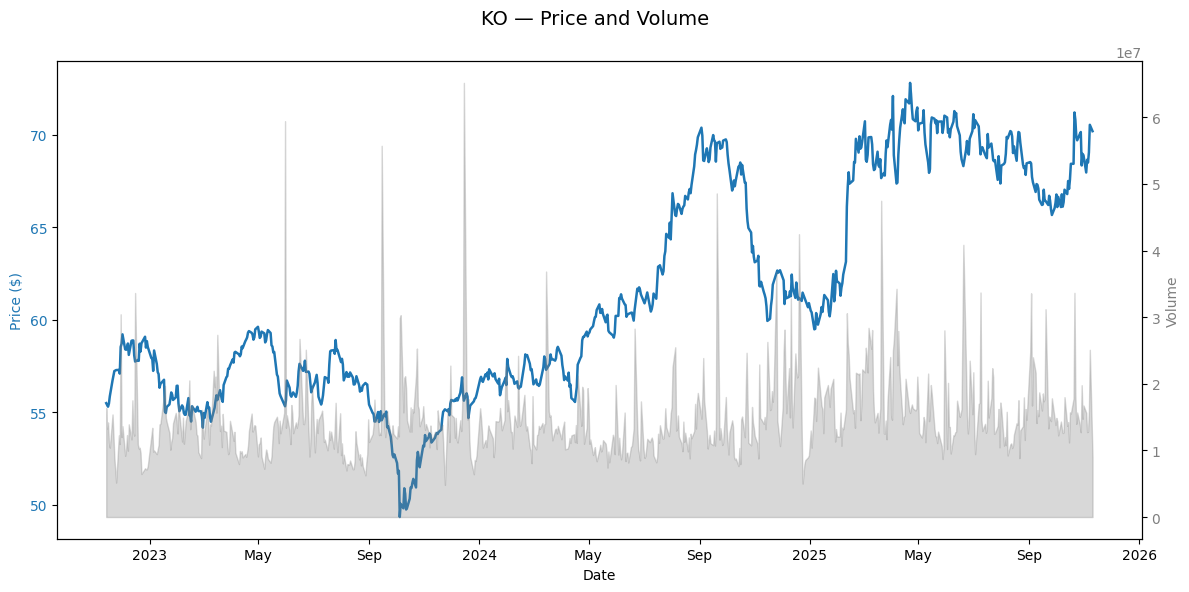

In [4]:
def plot_price_volume(df: pd.DataFrame, ticker: str):
    """
    Plots closing price and trading volume for visual inspection.
    Handles both single-level and multi-level DataFrame columns.
    """
    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [f"{col[0].lower()}_{col[1].lower()}" for col in df.columns]
    else:
        df.columns = [c.lower() for c in df.columns]

    close_candidates = [c for c in df.columns if "close" in c and ticker.lower() in c]
    volume_candidates = [c for c in df.columns if "volume" in c and ticker.lower() in c]

    close_col = close_candidates[0] if close_candidates else "close"
    volume_col = volume_candidates[0] if volume_candidates else "volume"

    if close_col not in df.columns or volume_col not in df.columns:
        raise ValueError(f"Could not find 'close' or 'volume' columns for {ticker}. Columns: {list(df.columns)}")

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(df.index, df[close_col], color='tab:blue', linewidth=1.8, label='Close Price')
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Price ($)", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax1.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax1.xaxis.get_major_locator()))

    ax2 = ax1.twinx()
    ax2.fill_between(df.index, df[volume_col], color='tab:gray', alpha=0.3)
    ax2.set_ylabel("Volume", color='tab:gray')
    ax2.tick_params(axis='y', labelcolor='tab:gray')

    fig.suptitle(f"{ticker} — Price and Volume", fontsize=14)
    fig.tight_layout()
    plt.show()

plot_price_volume(df, ticker)


In [5]:
def check_data_quality(df: pd.DataFrame):
    """
    Simple outlier detection.
    """
    numeric_cols = df.select_dtypes(include='number')
    z_scores = (numeric_cols - numeric_cols.mean()) / numeric_cols.std()
    outlier_ratio = (abs(z_scores) > 3).sum() / len(df)
    print("Potential outlier ratio per column:")
    print(outlier_ratio)

check_data_quality(df)

Potential outlier ratio per column:
Price   Ticker
close   ko        0.00
high    ko        0.00
low     ko        0.00
open    ko        0.00
volume  ko        0.02
dtype: float64


Daily return and volume distributions are also examined. The histogram shows that most daily returns are within ±1%, with occasional larger moves, while the volume distribution highlights periods of higher trading activity. This offers an understanding of daily price variations and volatility patterns ahead of modeling. 

--- KO Daily Return Summary (in %) ---
count    749.000000
mean       0.035722
std        0.928872
min       -4.832832
0.1%      -4.539824
1%        -2.168446
50%        0.033079
99%        2.375779
99.9%      4.229045
max        4.725025
Name: daily_return_pct, dtype: float64

Total days: 749
Days with daily return within ±1%: 581 (77.6%)
Days with daily return >±1% and ≤±2%: 142 (19.0%)
Days with daily return >±2% and ≤±5%: 26 (3.5%)
Days with daily return >±5%: 0 (0.0%)


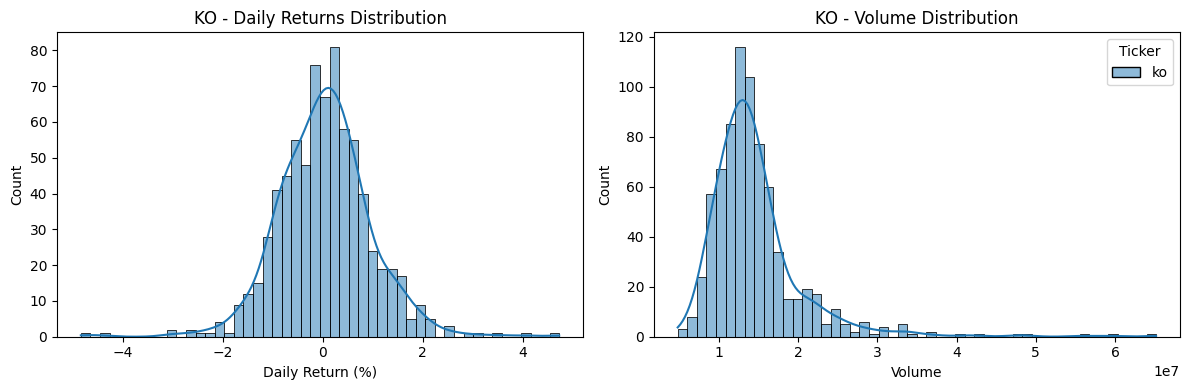

In [6]:
def plot_distributions(df: pd.DataFrame, ticker: str):
    """
    Plots histograms for price returns and volume distributions.
    Also prints descriptive statistics and counts of daily returns within specific ranges.
    """
    df = df.copy()
    df['daily_return'] = df['close'].pct_change()
    df['daily_return_pct'] = df['daily_return'] * 100
    
    print(f"--- {ticker} Daily Return Summary (in %) ---")
    print(df['daily_return_pct'].describe(percentiles=[0.001, 0.01, 0.99, 0.999]))
    
    total_days = len(df['daily_return'].dropna())
    within_1pct = ((df['daily_return'] >= -0.01) & (df['daily_return'] <= 0.01)).sum()
    between_1_2pct = (((df['daily_return'] > 0.01) & (df['daily_return'] <= 0.02)) | 
                    ((df['daily_return'] < -0.01) & (df['daily_return'] >= -0.02))).sum()
    between_2_5pct = (((df['daily_return'] > 0.02) & (df['daily_return'] <= 0.05)) | 
                    ((df['daily_return'] < -0.02) & (df['daily_return'] >= -0.05))).sum()
    above_5pct = ((df['daily_return'] > 0.05) | (df['daily_return'] < -0.05)).sum()

    print(f"\nTotal days: {total_days}")
    print(f"Days with daily return within ±1%: {within_1pct} ({within_1pct/total_days:.1%})")
    print(f"Days with daily return >±1% and ≤±2%: {between_1_2pct} ({between_1_2pct/total_days:.1%})")
    print(f"Days with daily return >±2% and ≤±5%: {between_2_5pct} ({between_2_5pct/total_days:.1%})")
    print(f"Days with daily return >±5%: {above_5pct} ({above_5pct/total_days:.1%})")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(df['daily_return_pct'].dropna(), bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f"{ticker} - Daily Returns Distribution")
    axes[0].set_xlabel("Daily Return (%)")
    
    sns.histplot(df['volume'].dropna(), bins=50, kde=True, ax=axes[1])
    axes[1].set_title(f"{ticker} - Volume Distribution")
    axes[1].set_xlabel("Volume")
    
    plt.tight_layout()
    plt.show()

plot_distributions(df, ticker)

## Feature engineering

Before feeding the stock data into a predictive model, it is important to transform raw OHLCV (Open, High, Low, Close, Volume) data into features that capture relevant patterns for forecasting the next day’s price. The daily stock data is transformed into a format suitable for machine learning, where information from previous days is used to help predict the next day’s closing price. Two approaches are explored: first, using only lagged OHLCV values as features, and second, augmenting the data with technical indicators commonly used in trading analysis. This allows us to compare whether adding technical indicators improves the model’s predictive accuracy. 

Technical indicators summarize price behavior and trends over time. Features such as moving averages (MA), relative strength index (RSI), momentum, volatility, MACD, and Bollinger Bands are included in the model. These indicators may capture patterns like short-term trends, overbought or oversold conditions, and price volatility, potentially providing the model with more predictive power than raw OHLCV alone. 

In [7]:
def create_features(data: pd.DataFrame, lag: int = 3, use_ta: bool = False):
    """
    Converts OHLCV data into supervised learning features for next-day prediction.

    Args:
        data (pd.DataFrame): Daily stock data with columns ['open','high','low','close','volume']
        lag (int): Number of past days used as features
        use_ta (bool): Use TA features

    Returns:
        X (pd.DataFrame): Feature matrix
        y (pd.Series): Target values (next-day close)
    """
    df = data.copy()

    if use_ta:
        df["return"] = df["close"].pct_change()
        df["ma_5"] = df["close"].rolling(5).mean()
        df["ma_20"] = df["close"].rolling(20).mean()
        df["momentum"] = df["close"] / df["close"].shift(5) - 1
        df["volatility"] = df["return"].rolling(10).std()

        close = df["close"]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        rsi = ta.momentum.RSIIndicator(close.squeeze(), window=14).rsi()
        macd = ta.trend.MACD(close.squeeze()).macd()
        bb = ta.volatility.BollingerBands(close.squeeze())

        df["rsi"] = np.array(rsi).flatten()
        df["macd"] = np.array(macd).flatten()
        df["bb_high"] = np.array(bb.bollinger_hband()).flatten()
        df["bb_low"] = np.array(bb.bollinger_lband()).flatten()


    df = df.dropna()

    features = []
    targets = []
    target_dates = []
    feature_dates = []

    for i in range(lag, len(df)):
        window = df.iloc[i - lag:i]
        next_close = df.iloc[i]["close"]
        next_date = df.index[i]
        window_dates = df.index[i - lag:i]

        feat = window.values.flatten()
        features.append(feat)
        targets.append(next_close)
        target_dates.append(next_date)
        feature_dates.append(window_dates)

    X = np.array(features)
    y = np.array(targets).flatten()
    target_dates = np.array(target_dates)
    return X, y, target_dates, feature_dates

## Model Training and Evaluation 

Once the features are prepared, the next step is to train and evaluate the predictive model. The model is repeatedly trained on a rolling window of past data and tested on the following day’s price, mimicking real trading conditions. This walk-forward validation ensures that predictions are always made using only historical information, closely reflecting how a trader would use the model in practice. 

In [8]:
def walk_forward_sliding_window(X, y, target_dates, train_window=100, step=1, params=None):
    """
    Walk-forward validation with a sliding training window for next-day stock prediction.

    Args:
        X (np.ndarray): Feature matrix
        y (np.ndarray): Target vector
        target_dates (np.ndarray): Corresponding dates
        train_window (int): Number of past samples used for training at each step
        step (int): How many steps to move the window forward each iteration
        params (dict): Hyperparameters for XGBRegressor

    Returns:
        results (pd.DataFrame): DataFrame with date, actual, predicted
        metrics (dict): Overall MAE and RMSE
    """
    if params is None:
        params = {
            "n_estimators": 600,
            "learning_rate": 0.03,
            "max_depth": 5,
            "min_child_weight": 5,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "gamma": 0.2,
            "reg_lambda": 2.0,
            "reg_alpha": 0.5,
            "objective": "reg:squarederror",
            "eval_metric": "mae",
            "random_state": 42,
        }

    n_samples = len(X)
    predictions = []
    actuals = []
    dates = []

    start_idx = train_window
    for i in range(start_idx, n_samples, step):
        train_idx = slice(i - train_window, i)
        test_idx = i

        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx:test_idx+1], y[test_idx:test_idx+1]

        model = XGBRegressor(**params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        predictions.append(y_pred[0])
        actuals.append(y_test[0])
        dates.append(target_dates[test_idx])

    results = pd.DataFrame({
        "date": dates,
        "actual": actuals,
        "predicted": predictions
    }).set_index("date")

    mae = mean_absolute_error(results["actual"], results["predicted"])
    rmse = root_mean_squared_error(results["actual"], results["predicted"])
    r2 = r2_score(results["actual"], results["predicted"])
    mape = np.mean(np.abs((results["actual"] - results["predicted"]) / results["actual"])) * 100

    # Directional Accuracy (DA)
    actual_change = np.sign(results["actual"].diff())
    predicted_change = np.sign(results["predicted"].diff())
    da = np.mean(actual_change[1:] == predicted_change[1:]) * 100

    metrics = {
        "MAE": mae,
        "MAPE": mape,
        #"RMSE": rmse,
        "R2": r2,
        "Directional_Accuracy": da
    }

    print(f"MAE: {mae:.3f}, MAPE: {mape:.3f}%, R²: {r2:.2f}, DA: {da:.2f}%")

    return results, metrics

Different configurations are tested, including how many past days to use as input and the size of the training window. The optimal values for these parameters are not universal, they differ between stocks due to variations in volatility, liquidity, and trading patterns. For example, a highly volatile stock may benefit from a shorter lag to capture rapid changes, while a more stable stock may require a longer training window to learn meaningful trends. 

In [9]:
def optimize_window_sizes(data, lag_values, train_window_values, use_ta):
    """
    Simple grid search over lag and train_window sizes using walk-forward validation.

    Args:
        data (pd.DataFrame): Stock data (OHLCV)
        lag_values (list): Candidate lag values (e.g. [5, 10, 20, 30])
        train_window_values (list): Candidate train_window sizes (e.g. [50, 100, 200])
        ticker (str): Ticker symbol for reporting

    Returns:
        pd.DataFrame: Results sorted by MAE
    """
    results_summary = []

    for lag in lag_values:
        X, y, target_dates, _ = create_features(data, lag, use_ta)
        for tw in train_window_values:
            if tw >= len(X) // 2:
                continue
            print(f"\nTesting lag={lag}, train_window={tw}...")
            try:
                _, metrics = walk_forward_sliding_window(X, y, target_dates, train_window=tw)
                results_summary.append({
                    "lag": lag,
                    "train_window": tw,
                    **metrics
                })
            except Exception as e:
                print(f"  Failed for lag={lag}, train_window={tw}: {e}")

    df_results = pd.DataFrame(results_summary)
    df_results = df_results.sort_values("MAPE")
    print("\n=== Optimization Results (sorted by MAPE) ===")
    print(df_results.head(20))
    return df_results

## Test with OHLCV + TA metrics

Models are compared both with raw OHLCV data and with additional technical indicators to see if these improve predictive accuracy. The evaluation includes error metrics like mean absolute error (MAE) and root mean squared error (RMSE), as well as directional accuracy, which measures how often the model correctly predicts the next day’s price movement. This systematic testing allows us to select the best configuration for each stock before generating final predictions. 

Although several years of historical stock data is collected for model development, the final prediction for tomorrow’s price uses only the most recent portion of data defined by the selected training window. The longer history is primarily used to test different configurations. This includes how many past days to use as input (lag) and the size of the training window. These tests allow identification of the setup that performs best. Once these parameters are determined, the model only “looks back” at the recent window of data when making the actual next-day prediction, just as a trader would rely on the latest market information. 

In [ ]:
ticker = "KO"
years = 1
data = load_stock_data(ticker, years)

lag_values = [2, 3, 4, 5]
train_window_values = [70, 80, 90, 100, 120, 140, 160]

use_ta = False
results_base_1year = optimize_window_sizes(data, lag_values, train_window_values, use_ta)
best_base_1year = results_base_1year.iloc[0]
print(f"\nBest configuration without TA: lag={best_base_1year.lag}, train_window={best_base_1year.train_window}")

use_ta = True
results_ta_1year = optimize_window_sizes(data, lag_values, train_window_values, use_ta)
best_ta_1year = results_ta_1year.iloc[0]
print(f"\nBest configuration with TA: lag={best_ta_1year.lag}, train_window={best_ta_1year.train_window}")

print("\n=== Comparison ===")
print("Without TA:")
print(best_base_1year)
print("\nWith TA:")
print(best_ta_1year)

Fetching 1 year(s) of data for KO (2024-11-11 - 2025-11-11)...

Testing lag=2, train_window=70...
MAE: 0.673, MAPE: 0.972%, R²: 0.71, DA: 47.46%

Testing lag=2, train_window=80...
MAE: 0.684, MAPE: 0.987%, R²: 0.72, DA: 48.50%

Testing lag=2, train_window=90...
MAE: 0.662, MAPE: 0.955%, R²: 0.74, DA: 49.68%

Testing lag=2, train_window=100...
MAE: 0.625, MAPE: 0.903%, R²: 0.77, DA: 55.10%

Testing lag=2, train_window=120...
MAE: 0.613, MAPE: 0.891%, R²: 0.72, DA: 55.91%

Testing lag=3, train_window=70...
MAE: 0.691, MAPE: 0.997%, R²: 0.69, DA: 51.70%

Testing lag=3, train_window=80...
MAE: 0.691, MAPE: 0.998%, R²: 0.70, DA: 49.40%

Testing lag=3, train_window=90...
MAE: 0.657, MAPE: 0.948%, R²: 0.74, DA: 50.00%

Testing lag=3, train_window=100...
MAE: 0.623, MAPE: 0.899%, R²: 0.77, DA: 47.95%

Testing lag=3, train_window=120...
MAE: 0.607, MAPE: 0.882%, R²: 0.74, DA: 49.21%

Testing lag=4, train_window=70...
MAE: 0.694, MAPE: 1.002%, R²: 0.69, DA: 49.14%

Testing lag=4, train_window=80

In [11]:
def plot_walk_forward_results(results: pd.DataFrame, ticker: str = "MSFT"):
    """
    Plots walk-forward prediction results:
    - Actual vs predicted prices
    - Prediction error over time

    Args:
        results (pd.DataFrame): DataFrame with 'actual' and 'predicted' columns indexed by date
        ticker (str): Stock ticker for title
    """
    fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                           gridspec_kw={'height_ratios': [3, 1]})

    ax[0].plot(results.index, results["actual"], label="Actual", color="black")
    ax[0].plot(results.index, results["predicted"], label="Predicted", color="red", alpha=0.7)
    ax[0].set_ylabel("Close Price")
    ax[0].set_title(f"{ticker} — Next-Day Close Prediction (Walk-Forward, Sliding Window)")
    ax[0].legend(loc="upper left")
    ax[0].grid(True, linestyle="--", alpha=0.4)

    #errors = results["predicted"] - results["actual"]
    errors = (results["predicted"] - results["actual"]) / results["actual"] * 100
    ax[1].plot(results.index, errors, color="blue", alpha=0.6)
    ax[1].axhline(0, color="black", linewidth=1)
    ax[1].set_ylabel("Relative Error (%)")
    ax[1].set_xlabel("Date")
    ax[1].grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

## Hyperparameter Optimization 

The model’s predictive performance is further improved by tuning its hyperparameters with Optuna. Optuna systematically explores many combinations of parameters, evaluating each configuration using the walk-forward validation process. 

Different optimization goals can be targeted, such as minimizing MAE, MAPE, or maximizing directional accuracy, depending on whether the focus is on precise price prediction or correctly forecasting price movement direction. By combining historical data, lagged features, and technical indicators, Optuna helps identify the hyperparameter settings that provide the best balance of accuracy and robustness for each individual stock. 

In [ ]:
def optuna_xgb(data, lag, train_window, n_trials=50, use_ta=True, metric="mape", alpha=None):
    X, y, dates, _ = create_features(data, lag, use_ta)

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_categorical("n_estimators", [200, 400, 600, 800]),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
            "random_state": 42,
            "objective": "reg:squarederror",
            "eval_metric": "mae",
        }
        _, metrics = walk_forward_sliding_window(
            X, y, dates, train_window=train_window, params=params, step=1
        )
        
        if metrics is None:
            return float("inf")
        
        mae = metrics["MAE"]
        mape = metrics["MAPE"]
        da = metrics["Directional_Accuracy"]
        trial.set_user_attr("MAE", mae)
        trial.set_user_attr("MAPE", mape)
        trial.set_user_attr("DA", da)

        if metric.lower() == "mae":
            return mae
        elif metric.lower() == "mape":
            return mape
        elif metric.lower() == "da":
            return -da
        elif metric.lower() == "composite": 
            alpha_val = 0.5 if alpha is None else alpha
            return mape - alpha_val * (da / 100)

        else:
            raise ValueError("metric must be 'mae', 'da', or 'composite'")

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    return study

### Optimizing objective: MAPE

In [39]:
lag = 3
train_window = 100
use_ta = True
objective = 'mape'

study_mape = optuna_xgb(
    data, 
    lag=lag, 
    train_window=train_window, 
    n_trials=50, 
    use_ta=use_ta, 
    metric=objective, 
    alpha=None
)

[I 2025-11-11 09:19:34,437] A new study created in memory with name: no-name-a17d96fe-fd70-408d-92de-5cef310a47c6
[I 2025-11-11 09:20:23,534] Trial 0 finished with value: 0.9633153587647787 and parameters: {'n_estimators': 400, 'learning_rate': 0.013718709731802907, 'max_depth': 6, 'subsample': 0.5138199785288817, 'colsample_bytree': 0.942926228323228, 'reg_alpha': 3.1096228576794536, 'reg_lambda': 0.25811788251322965}. Best is trial 0 with value: 0.9633153587647787.


MAE: 0.659, MAPE: 0.963%, R²: 0.68, DA: 45.45%


[I 2025-11-11 09:21:03,212] Trial 1 finished with value: 0.8566509724177888 and parameters: {'n_estimators': 600, 'learning_rate': 0.06408695892481406, 'max_depth': 4, 'subsample': 0.8758080008316622, 'colsample_bytree': 0.7398572751511627, 'reg_alpha': 1.5438980848551025, 'reg_lambda': 4.175137578676086}. Best is trial 1 with value: 0.8566509724177888.


MAE: 0.588, MAPE: 0.857%, R²: 0.74, DA: 46.28%


[I 2025-11-11 09:21:35,010] Trial 2 finished with value: 0.9194370189817563 and parameters: {'n_estimators': 400, 'learning_rate': 0.029237445918915077, 'max_depth': 3, 'subsample': 0.7508718399827299, 'colsample_bytree': 0.8366176085246493, 'reg_alpha': 4.573938501023918, 'reg_lambda': 4.608661149788723}. Best is trial 1 with value: 0.8566509724177888.


...

MAE: 0.615, MAPE: 0.896%, R²: 0.72, DA: 47.11%


[I 2025-11-11 10:12:18,777] Trial 48 finished with value: 0.9373761164120322 and parameters: {'n_estimators': 800, 'learning_rate': 0.04583093691425609, 'max_depth': 6, 'subsample': 0.5664817194878435, 'colsample_bytree': 0.610982422379704, 'reg_alpha': 3.42335652677375, 'reg_lambda': 0.9487085877627226}. Best is trial 42 with value: 0.7505172939546145.


MAE: 0.642, MAPE: 0.937%, R²: 0.69, DA: 43.80%


[I 2025-11-11 10:12:48,343] Trial 49 finished with value: 0.7652105654393758 and parameters: {'n_estimators': 400, 'learning_rate': 0.054719614803654254, 'max_depth': 3, 'subsample': 0.5033812328794689, 'colsample_bytree': 0.5604089855805048, 'reg_alpha': 0.26796981308112616, 'reg_lambda': 0.29272411675047705}. Best is trial 42 with value: 0.7505172939546145.


MAE: 0.527, MAPE: 0.765%, R²: 0.79, DA: 51.24%


In [40]:
print(f"\n=== Optuna optimization finished, objective: {objective} ===")
print("Best objective value:", study_mape.best_value)
print("Best parameters:")
for k, v in study_mape.best_params.items():
    print(f"  {k}: {v}")

best_trial = study_mape.best_trial
print(f"\nBest MAPE: {best_trial.user_attrs['MAPE']:.5f}")
print(f"Best Directional Accuracy: {best_trial.user_attrs['DA']:.2f}%")


=== Optuna optimization finished, objective: mape ===
Best objective value: 0.7505172939546145
Best parameters:
  n_estimators: 800
  learning_rate: 0.035374768752997214
  max_depth: 3
  subsample: 0.5773286360058645
  colsample_bytree: 0.641445161177692
  reg_alpha: 0.3608097163587702
  reg_lambda: 0.2831449664721421

Best MAPE: 0.75052
Best Directional Accuracy: 55.37%


MAE: 0.542, MAPE: 0.787%, R²: 0.78, DA: 46.28%
Objective mape

Walk-forward metrics with best params:
{'MAE': 0.5416437993284131, 'MAPE': np.float64(0.787081550532762), 'R2': 0.7814340479390374, 'Directional_Accuracy': np.float64(46.28099173553719)}


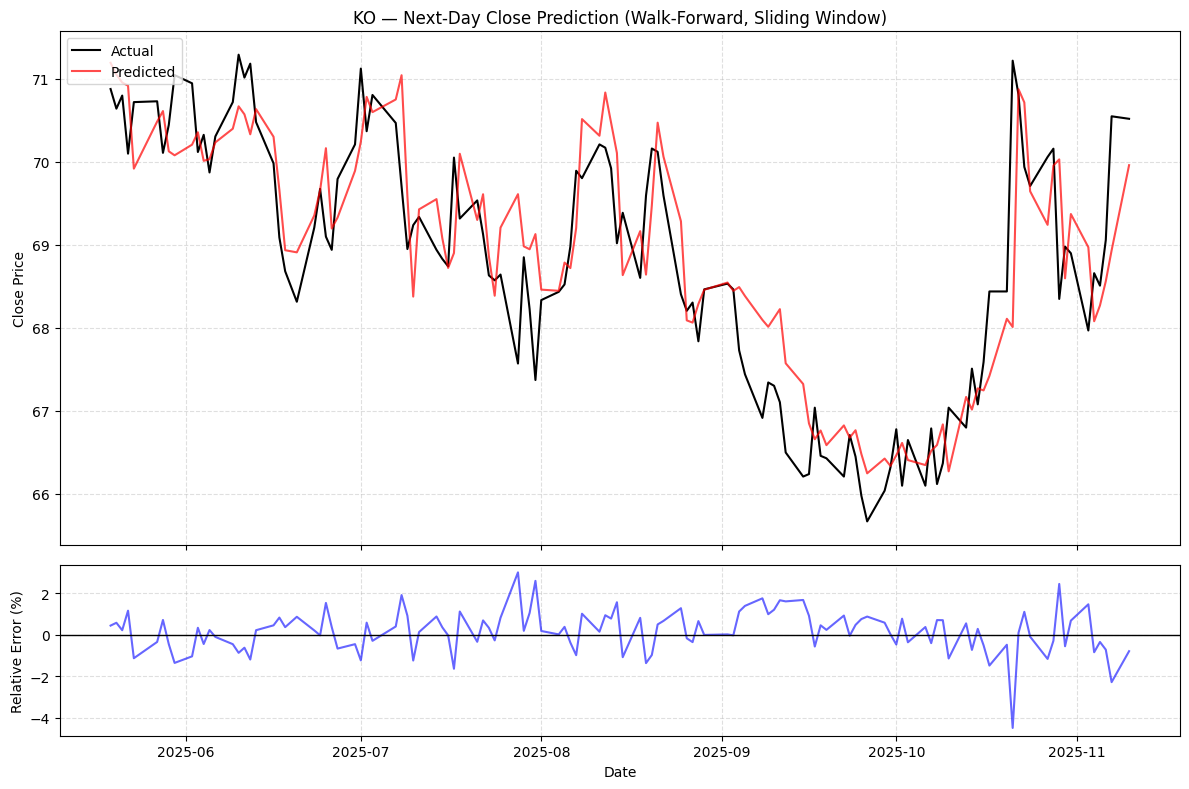

In [41]:
X, y, target_dates, feature_dates = create_features(data, lag, use_ta=True)

results, metrics = walk_forward_sliding_window(
    X, y, target_dates,
    train_window=train_window,
    step=1,
    params=study_mape.best_params,
)

print(f"Objective {objective}")
print("\nWalk-forward metrics with best params:")
print(metrics)

plot_walk_forward_results(results, ticker)

### Combined optimizing objective: MAPE + DA

In [42]:
alpha = 0.3
objective = 'composite'

study_combo = optuna_xgb(
    data, 
    lag=lag, 
    train_window=train_window, 
    n_trials=50, 
    use_ta=True, 
    metric=objective,
    alpha=alpha
)

[I 2025-11-11 10:13:45,204] A new study created in memory with name: no-name-3ccbf395-8ead-45cc-9a3d-327f7dd2b2be
[I 2025-11-11 10:14:11,195] Trial 0 finished with value: 0.7141528867612512 and parameters: {'n_estimators': 200, 'learning_rate': 0.01865290643994106, 'max_depth': 4, 'subsample': 0.7744493261887417, 'colsample_bytree': 0.786850537078517, 'reg_alpha': 0.6681279219538955, 'reg_lambda': 1.6174701400922076}. Best is trial 0 with value: 0.7141528867612512.


MAE: 0.587, MAPE: 0.855%, R²: 0.75, DA: 47.11%


[I 2025-11-11 10:14:56,913] Trial 1 finished with value: 0.7693924383708961 and parameters: {'n_estimators': 400, 'learning_rate': 0.01931548262581412, 'max_depth': 4, 'subsample': 0.9267992525877118, 'colsample_bytree': 0.9779804317156561, 'reg_alpha': 3.517439400994535, 'reg_lambda': 0.9136691178145712}. Best is trial 0 with value: 0.7141528867612512.


MAE: 0.628, MAPE: 0.916%, R²: 0.70, DA: 48.76%


[I 2025-11-11 10:15:17,006] Trial 2 finished with value: 0.7819854338427439 and parameters: {'n_estimators': 200, 'learning_rate': 0.027712519660828883, 'max_depth': 4, 'subsample': 0.8206179913575109, 'colsample_bytree': 0.6042330223296927, 'reg_alpha': 2.8761264654397727, 'reg_lambda': 1.6359709687410033}. Best is trial 0 with value: 0.7141528867612512.


...

MAE: 0.564, MAPE: 0.821%, R²: 0.76, DA: 51.24%


[I 2025-11-11 10:59:58,435] Trial 48 finished with value: 0.7901144727330914 and parameters: {'n_estimators': 400, 'learning_rate': 0.042123233311419025, 'max_depth': 4, 'subsample': 0.6054863351814532, 'colsample_bytree': 0.8534920647393085, 'reg_alpha': 3.7763469739009015, 'reg_lambda': 0.8824990022490362}. Best is trial 3 with value: 0.5798878896820381.


MAE: 0.640, MAPE: 0.934%, R²: 0.70, DA: 47.93%


[I 2025-11-11 11:01:05,206] Trial 49 finished with value: 0.663777285574239 and parameters: {'n_estimators': 600, 'learning_rate': 0.05057886463345761, 'max_depth': 6, 'subsample': 0.6961785110978423, 'colsample_bytree': 0.943470924741233, 'reg_alpha': 0.6323177753732813, 'reg_lambda': 0.3891067398356719}. Best is trial 3 with value: 0.5798878896820381.


MAE: 0.557, MAPE: 0.810%, R²: 0.76, DA: 48.76%


In [43]:
print(f"\n=== Optuna optimization finished, objective: {objective} ===")
print("Best objective value:", study_combo.best_value)
print("Best parameters:")
for k, v in study_combo.best_params.items():
    print(f"  {k}: {v}")

best_trial = study_combo.best_trial
print(f"\nBest MAPE: {best_trial.user_attrs['MAPE']:.5f}")
print(f"Best Directional Accuracy: {best_trial.user_attrs['DA']:.2f}%")


=== Optuna optimization finished, objective: composite ===
Best objective value: 0.5798878896820381
Best parameters:
  n_estimators: 400
  learning_rate: 0.06569171193328727
  max_depth: 5
  subsample: 0.7718443939836293
  colsample_bytree: 0.8825828726244599
  reg_alpha: 0.03125984080292854
  reg_lambda: 0.5125378184902091

Best MAPE: 0.73361
Best Directional Accuracy: 51.24%


MAE: 0.529, MAPE: 0.768%, R²: 0.79, DA: 48.76%
Combined objective MAPE + DA

Walk-forward metrics with best params:
{'MAE': 0.5291931902775999, 'MAPE': np.float64(0.7679856677402456), 'R2': 0.7872459640629514, 'Directional_Accuracy': np.float64(48.760330578512395)}


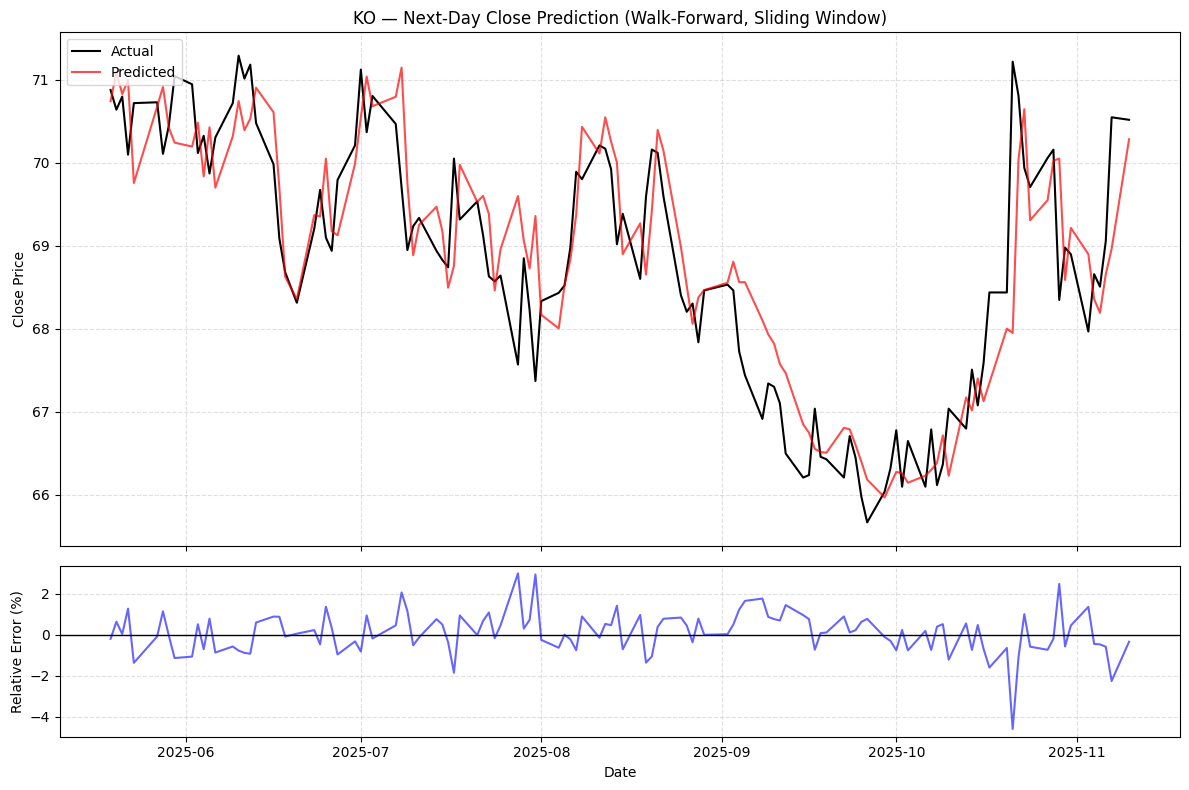

In [44]:
X, y, target_dates, feature_dates = create_features(data, lag, use_ta=True)

results, metrics = walk_forward_sliding_window(
    X, y, target_dates,
    train_window=train_window,
    step=1, # predict daily
    params=study_combo.best_params,
)

print("Combined objective MAPE + DA")
print("\nWalk-forward metrics with best params:")
print(metrics)

plot_walk_forward_results(results, ticker)

### Optimizing objective: DA

In [45]:
objective = 'da'

study_da = optuna_xgb(
    data, 
    lag=lag, 
    train_window=train_window, 
    n_trials=50, 
    use_ta=True, 
    metric=objective,
    alpha=None
)

[I 2025-11-11 11:02:06,519] A new study created in memory with name: no-name-05102d0b-03cf-437c-9a13-0c72d348ddb0
[I 2025-11-11 11:02:22,506] Trial 0 finished with value: -46.28099173553719 and parameters: {'n_estimators': 200, 'learning_rate': 0.010805366329127802, 'max_depth': 3, 'subsample': 0.8655148789284517, 'colsample_bytree': 0.571492966085026, 'reg_alpha': 4.357171909288525, 'reg_lambda': 2.0946871263677957}. Best is trial 0 with value: -46.28099173553719.


MAE: 0.750, MAPE: 1.098%, R²: 0.61, DA: 46.28%


[I 2025-11-11 11:02:56,906] Trial 1 finished with value: -43.80165289256198 and parameters: {'n_estimators': 800, 'learning_rate': 0.09400491772727665, 'max_depth': 4, 'subsample': 0.5945755782054114, 'colsample_bytree': 0.7187165483922373, 'reg_alpha': 4.5629025420164595, 'reg_lambda': 1.7609931889166708}. Best is trial 0 with value: -46.28099173553719.


MAE: 0.658, MAPE: 0.961%, R²: 0.68, DA: 43.80%


[I 2025-11-11 11:03:56,191] Trial 2 finished with value: -45.45454545454545 and parameters: {'n_estimators': 800, 'learning_rate': 0.015027894177648545, 'max_depth': 4, 'subsample': 0.8013697965015668, 'colsample_bytree': 0.7009294632480207, 'reg_alpha': 4.244761564732701, 'reg_lambda': 1.542880086681393}. Best is trial 0 with value: -46.28099173553719.


...

MAE: 0.672, MAPE: 0.981%, R²: 0.65, DA: 50.41%


[I 2025-11-11 11:54:48,409] Trial 48 finished with value: -53.71900826446281 and parameters: {'n_estimators': 600, 'learning_rate': 0.03656646812336099, 'max_depth': 7, 'subsample': 0.9983660424148888, 'colsample_bytree': 0.8668549659043229, 'reg_alpha': 3.224932078604741, 'reg_lambda': 0.28892152080044287}. Best is trial 43 with value: -56.19834710743802.


MAE: 0.680, MAPE: 0.993%, R²: 0.65, DA: 53.72%


[I 2025-11-11 11:55:31,793] Trial 49 finished with value: -51.2396694214876 and parameters: {'n_estimators': 600, 'learning_rate': 0.03616706785432309, 'max_depth': 7, 'subsample': 0.9967184197578659, 'colsample_bytree': 0.9801676162147908, 'reg_alpha': 3.1870498577995168, 'reg_lambda': 0.5887451210350236}. Best is trial 43 with value: -56.19834710743802.


MAE: 0.683, MAPE: 0.996%, R²: 0.65, DA: 51.24%


In [46]:
print(f"\n=== Optuna optimization finished, objective: {objective} ===")
print("Best objective value:", study_da.best_value)
print("Best parameters:")
for k, v in study_da.best_params.items():
    print(f"  {k}: {v}")

best_trial = study_da.best_trial
print(f"\nBest MAPE: {best_trial.user_attrs['MAPE']:.5f}")
print(f"Best Directional Accuracy: {best_trial.user_attrs['DA']:.2f}%")


=== Optuna optimization finished, objective: da ===
Best objective value: -56.19834710743802
Best parameters:
  n_estimators: 600
  learning_rate: 0.031948530639794456
  max_depth: 6
  subsample: 0.9839298215659371
  colsample_bytree: 0.9623607014629346
  reg_alpha: 3.268603726566716
  reg_lambda: 0.7598852642927915

Best MAPE: 0.95968
Best Directional Accuracy: 56.20%


MAE: 0.661, MAPE: 0.964%, R²: 0.67, DA: 52.89%
Objective DA

Walk-forward metrics with best params:
{'MAE': 0.6605719894659324, 'MAPE': np.float64(0.9636939070911864), 'R2': 0.6661610381681484, 'Directional_Accuracy': np.float64(52.892561983471076)}


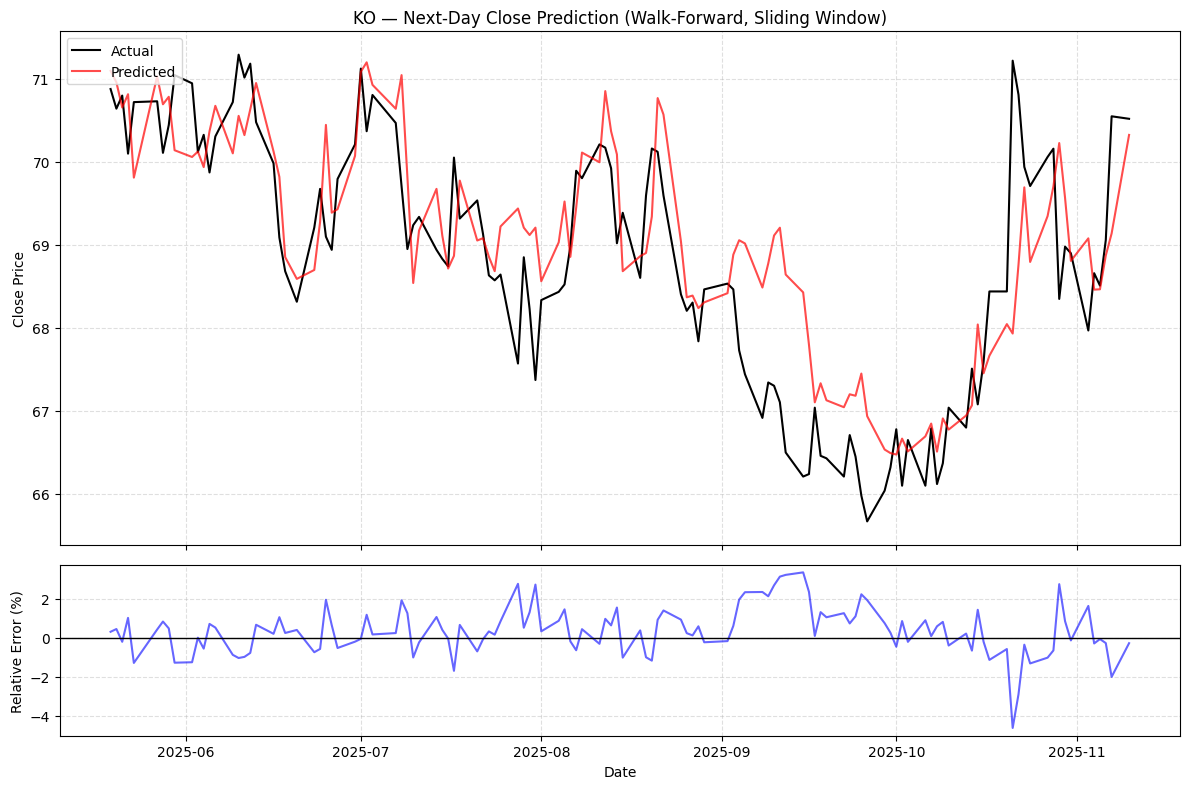

In [47]:
X, y, target_dates, feature_dates = create_features(data, lag, use_ta=True)

results, metrics = walk_forward_sliding_window(
    X, y, target_dates,
    train_window=train_window,
    step=1,
    params=study_da.best_params,
)

print("Objective DA")
print("\nWalk-forward metrics with best params:")
print(metrics)

plot_walk_forward_results(results, ticker)

## Feature Importance

Feature importance analysis was performed using the trained XGBoost model to identify which inputs most influenced next-day stock price predictions. The model assigns a numerical importance score to each feature, allowing for the ranking of past OHLCV values and technical indicators. Analysis of the most recent training window shows that short-term lagged prices, moving averages, and RSI tend to have the highest impact, while other features contribute less. Visualizing the top 20 features highlights which historical data points and technical indicators the model relies on most.

In [48]:
def get_feature_names(df, lag):
    base_cols = df.columns.tolist()
    feature_names = []
    for i in range(lag, 0, -1):
        for col in base_cols:
            feature_names.append(f"{col}_t-{i}")
    return feature_names

In [49]:
def get_feature_importance(data, lag, train_window, params, use_ta=True):
    X, y, target_dates, _ = create_features(data, lag, use_ta)
    n_samples = len(X)
    
    # Take the most recent data
    X_train = X[-train_window:]
    y_train = y[-train_window:]
    
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    
    importances = model.feature_importances_

    df_tmp = data.copy()
    if use_ta:
        df_tmp["return"] = df_tmp["close"].pct_change()
        df_tmp["ma_5"] = df_tmp["close"].rolling(5).mean()
        df_tmp["ma_20"] = df_tmp["close"].rolling(20).mean()
        df_tmp["momentum"] = df_tmp["close"] / df_tmp["close"].shift(5) - 1
        df_tmp["volatility"] = df_tmp["return"].rolling(10).std()

        close = df_tmp["close"]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        rsi = ta.momentum.RSIIndicator(close.squeeze(), window=14).rsi()
        macd = ta.trend.MACD(close.squeeze()).macd()
        bb = ta.volatility.BollingerBands(close.squeeze())

        df_tmp["rsi"] = np.array(rsi).flatten()
        df_tmp["macd"] = np.array(macd).flatten()
        df_tmp["bb_high"] = np.array(bb.bollinger_hband()).flatten()
        df_tmp["bb_low"] = np.array(bb.bollinger_lband()).flatten()
        df_tmp = df_tmp.dropna()

    feature_names = get_feature_names(df_tmp, lag)
    
    sorted_idx_all = np.argsort(importances)[::-1]

    print("\n=== All Feature Importances (Sorted) ===")
    for i in sorted_idx_all:
        print(f"{feature_names[i]}: {importances[i]:.5f}")

    return importances, feature_names

In [50]:
def plot_features(importances, feature_names):
    sorted_idx = np.argsort(importances)[::-1][:20]
    plt.figure(figsize=(10, 5))
    plt.barh([feature_names[i] for i in sorted_idx[::-1]],
             importances[sorted_idx[::-1]])
    plt.title("Top 20 XGBoost Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

In [51]:
def prune_features_by_importance(data, lag, train_window, params, use_ta=True, threshold=0.001):
    """
    Uses get_feature_importance() to drop low-importance features and re-trains the model.
    """
    importances, feature_names = get_feature_importance(data, lag, train_window, params, use_ta)

    kept_indices = [i for i, imp in enumerate(importances) if imp > threshold]
    kept_features = [feature_names[i] for i in kept_indices]

    print(f"\nKeeping {len(kept_features)} / {len(feature_names)} features (importance > {threshold})")

    X, y, target_dates, _ = create_features(data, lag, use_ta)
    X_reduced = X[:, kept_indices]

    _, metrics = walk_forward_sliding_window(X_reduced, y, target_dates, train_window=train_window, params=params)

    print("\n=== Performance After Feature Pruning ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    return kept_features, metrics


=== All Feature Importances (Sorted) ===
('low', 'ko')_t-2: 0.27344
('low', 'ko')_t-1: 0.13109
('high', 'ko')_t-1: 0.09767
('close', 'ko')_t-1: 0.09749
('low', 'ko')_t-3: 0.06477
('high', 'ko')_t-2: 0.03151
('momentum', '')_t-1: 0.02881
('rsi', '')_t-1: 0.02810
('ma_5', '')_t-1: 0.01816
('open', 'ko')_t-2: 0.01708
('volatility', '')_t-1: 0.01367
('close', 'ko')_t-2: 0.01232
('volatility', '')_t-2: 0.01201
('macd', '')_t-2: 0.01069
('volatility', '')_t-3: 0.01065
('bb_high', '')_t-3: 0.00941
('ma_20', '')_t-3: 0.00936
('rsi', '')_t-2: 0.00928
('ma_5', '')_t-2: 0.00863
('open', 'ko')_t-3: 0.00822
('macd', '')_t-3: 0.00817
('close', 'ko')_t-3: 0.00813
('bb_high', '')_t-2: 0.00801
('return', '')_t-1: 0.00729
('bb_high', '')_t-1: 0.00696
('ma_5', '')_t-3: 0.00687
('momentum', '')_t-2: 0.00671
('high', 'ko')_t-3: 0.00602
('rsi', '')_t-3: 0.00550
('return', '')_t-2: 0.00488
('momentum', '')_t-3: 0.00451
('bb_low', '')_t-1: 0.00410
('macd', '')_t-1: 0.00395
('bb_low', '')_t-3: 0.00376
('volum

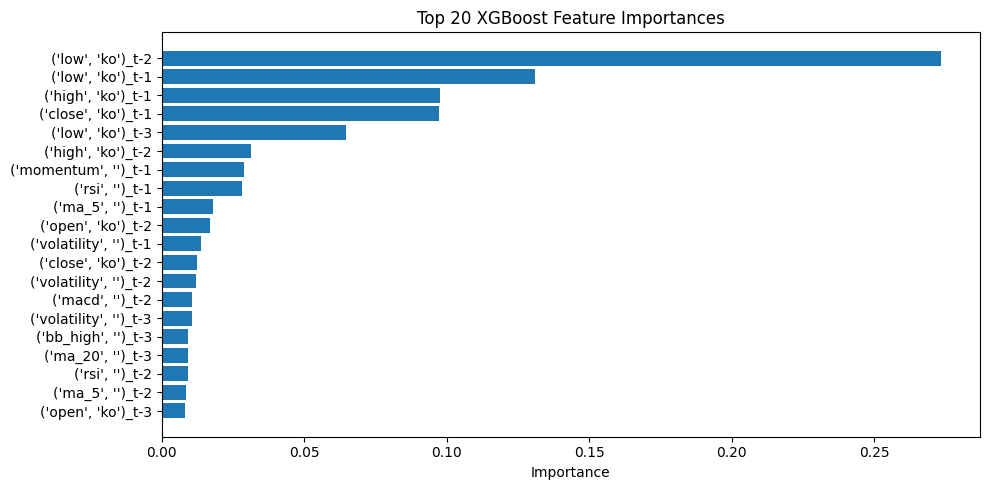

In [52]:
best_params = study_mape.best_params
importances, feature_names = get_feature_importance(data, lag, train_window, best_params, use_ta=True)
plot_features(importances, feature_names)

## Pruning Features

Pruning features based on importance scores allows the model to focus on inputs that contribute most to predictive performance. Features with importance below a chosen threshold are removed, and the model is retrained to assess the impact on metrics such as MAE, MAPE, and R². This process can improve model interpretability and reduce noise, but selecting the optimal threshold itself constitutes another optimization problem, as overly aggressive pruning may discard informative features while too lenient a threshold may retain irrelevant ones.

===Test pruning features===

Threshold = 0.001

=== All Feature Importances (Sorted) ===
('low', 'ko')_t-2: 0.27344
('low', 'ko')_t-1: 0.13109
('high', 'ko')_t-1: 0.09767
('close', 'ko')_t-1: 0.09749
('low', 'ko')_t-3: 0.06477
('high', 'ko')_t-2: 0.03151
('momentum', '')_t-1: 0.02881
('rsi', '')_t-1: 0.02810
('ma_5', '')_t-1: 0.01816
('open', 'ko')_t-2: 0.01708
('volatility', '')_t-1: 0.01367
('close', 'ko')_t-2: 0.01232
('volatility', '')_t-2: 0.01201
('macd', '')_t-2: 0.01069
('volatility', '')_t-3: 0.01065
('bb_high', '')_t-3: 0.00941
('ma_20', '')_t-3: 0.00936
('rsi', '')_t-2: 0.00928
('ma_5', '')_t-2: 0.00863
('open', 'ko')_t-3: 0.00822
('macd', '')_t-3: 0.00817
('close', 'ko')_t-3: 0.00813
('bb_high', '')_t-2: 0.00801
('return', '')_t-1: 0.00729
('bb_high', '')_t-1: 0.00696
('ma_5', '')_t-3: 0.00687
('momentum', '')_t-2: 0.00671
('high', 'ko')_t-3: 0.00602
('rsi', '')_t-3: 0.00550
('return', '')_t-2: 0.00488
('momentum', '')_t-3: 0.00451
('bb_low', '')_t-1: 0.00410
('macd', '')_t

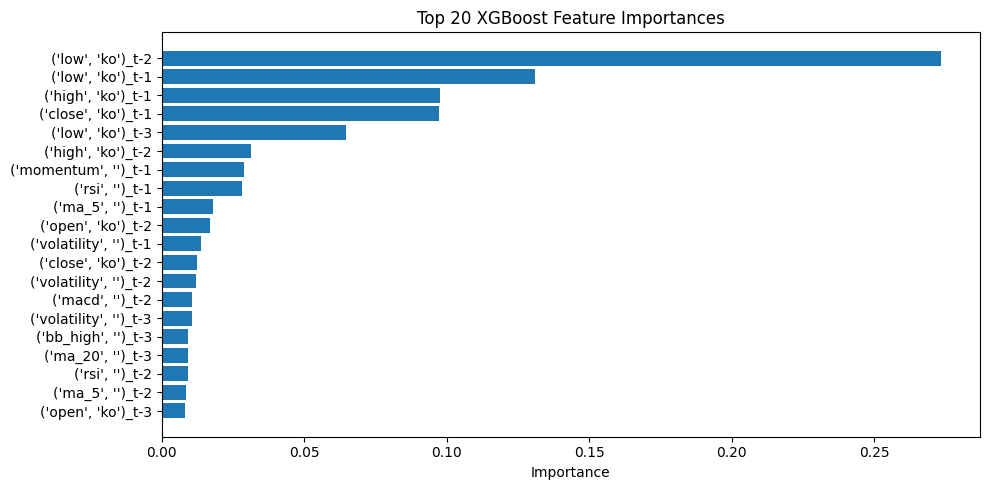

Last available date: 2025-11-10 00:00:00
Predicted close for next day: 70.50
Threshold = 0.005

=== All Feature Importances (Sorted) ===
('low', 'ko')_t-2: 0.27344
('low', 'ko')_t-1: 0.13109
('high', 'ko')_t-1: 0.09767
('close', 'ko')_t-1: 0.09749
('low', 'ko')_t-3: 0.06477
('high', 'ko')_t-2: 0.03151
('momentum', '')_t-1: 0.02881
('rsi', '')_t-1: 0.02810
('ma_5', '')_t-1: 0.01816
('open', 'ko')_t-2: 0.01708
('volatility', '')_t-1: 0.01367
('close', 'ko')_t-2: 0.01232
('volatility', '')_t-2: 0.01201
('macd', '')_t-2: 0.01069
('volatility', '')_t-3: 0.01065
('bb_high', '')_t-3: 0.00941
('ma_20', '')_t-3: 0.00936
('rsi', '')_t-2: 0.00928
('ma_5', '')_t-2: 0.00863
('open', 'ko')_t-3: 0.00822
('macd', '')_t-3: 0.00817
('close', 'ko')_t-3: 0.00813
('bb_high', '')_t-2: 0.00801
('return', '')_t-1: 0.00729
('bb_high', '')_t-1: 0.00696
('ma_5', '')_t-3: 0.00687
('momentum', '')_t-2: 0.00671
('high', 'ko')_t-3: 0.00602
('rsi', '')_t-3: 0.00550
('return', '')_t-2: 0.00488
('momentum', '')_t-3: 0.

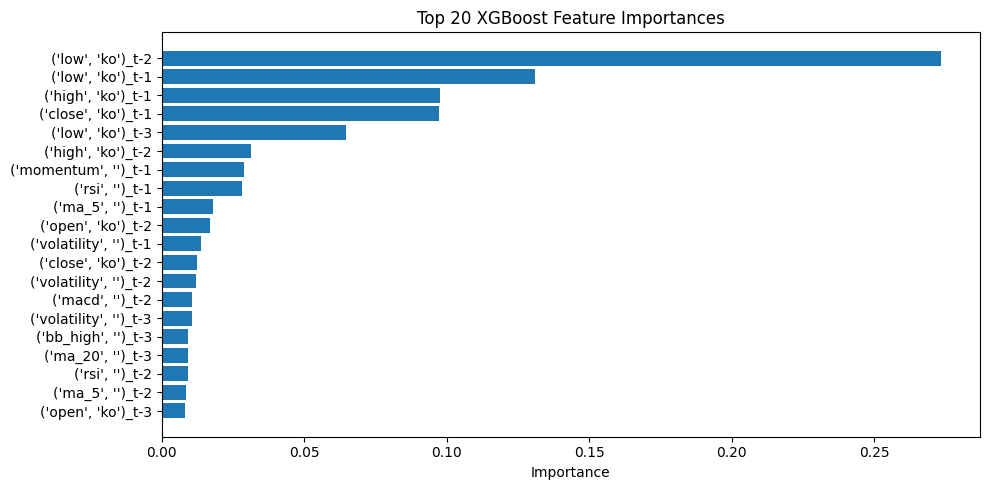

Last available date: 2025-11-10 00:00:00
Predicted close for next day: 70.50
Threshold = 0.01

=== All Feature Importances (Sorted) ===
('low', 'ko')_t-2: 0.27344
('low', 'ko')_t-1: 0.13109
('high', 'ko')_t-1: 0.09767
('close', 'ko')_t-1: 0.09749
('low', 'ko')_t-3: 0.06477
('high', 'ko')_t-2: 0.03151
('momentum', '')_t-1: 0.02881
('rsi', '')_t-1: 0.02810
('ma_5', '')_t-1: 0.01816
('open', 'ko')_t-2: 0.01708
('volatility', '')_t-1: 0.01367
('close', 'ko')_t-2: 0.01232
('volatility', '')_t-2: 0.01201
('macd', '')_t-2: 0.01069
('volatility', '')_t-3: 0.01065
('bb_high', '')_t-3: 0.00941
('ma_20', '')_t-3: 0.00936
('rsi', '')_t-2: 0.00928
('ma_5', '')_t-2: 0.00863
('open', 'ko')_t-3: 0.00822
('macd', '')_t-3: 0.00817
('close', 'ko')_t-3: 0.00813
('bb_high', '')_t-2: 0.00801
('return', '')_t-1: 0.00729
('bb_high', '')_t-1: 0.00696
('ma_5', '')_t-3: 0.00687
('momentum', '')_t-2: 0.00671
('high', 'ko')_t-3: 0.00602
('rsi', '')_t-3: 0.00550
('return', '')_t-2: 0.00488
('momentum', '')_t-3: 0.0

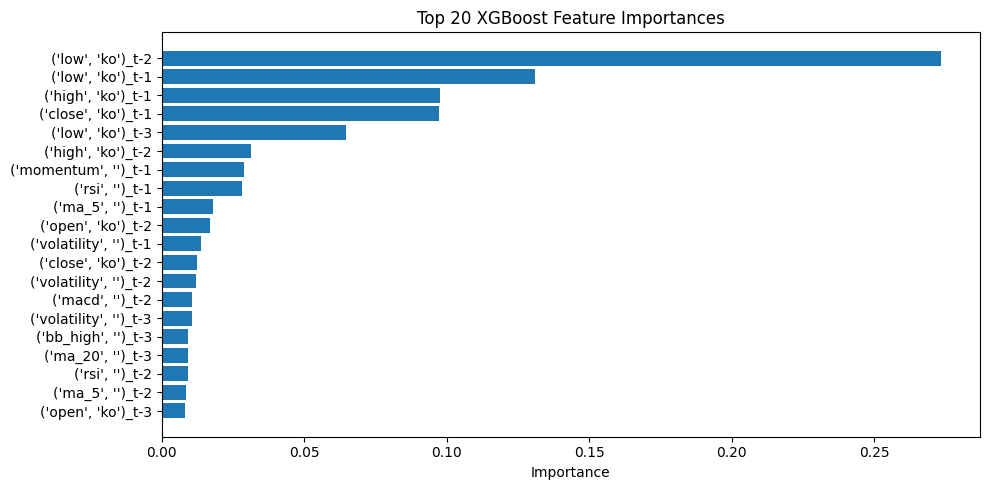

Last available date: 2025-11-10 00:00:00
Predicted close for next day: 70.50
Threshold = 0.02

=== All Feature Importances (Sorted) ===
('low', 'ko')_t-2: 0.27344
('low', 'ko')_t-1: 0.13109
('high', 'ko')_t-1: 0.09767
('close', 'ko')_t-1: 0.09749
('low', 'ko')_t-3: 0.06477
('high', 'ko')_t-2: 0.03151
('momentum', '')_t-1: 0.02881
('rsi', '')_t-1: 0.02810
('ma_5', '')_t-1: 0.01816
('open', 'ko')_t-2: 0.01708
('volatility', '')_t-1: 0.01367
('close', 'ko')_t-2: 0.01232
('volatility', '')_t-2: 0.01201
('macd', '')_t-2: 0.01069
('volatility', '')_t-3: 0.01065
('bb_high', '')_t-3: 0.00941
('ma_20', '')_t-3: 0.00936
('rsi', '')_t-2: 0.00928
('ma_5', '')_t-2: 0.00863
('open', 'ko')_t-3: 0.00822
('macd', '')_t-3: 0.00817
('close', 'ko')_t-3: 0.00813
('bb_high', '')_t-2: 0.00801
('return', '')_t-1: 0.00729
('bb_high', '')_t-1: 0.00696
('ma_5', '')_t-3: 0.00687
('momentum', '')_t-2: 0.00671
('high', 'ko')_t-3: 0.00602
('rsi', '')_t-3: 0.00550
('return', '')_t-2: 0.00488
('momentum', '')_t-3: 0.0

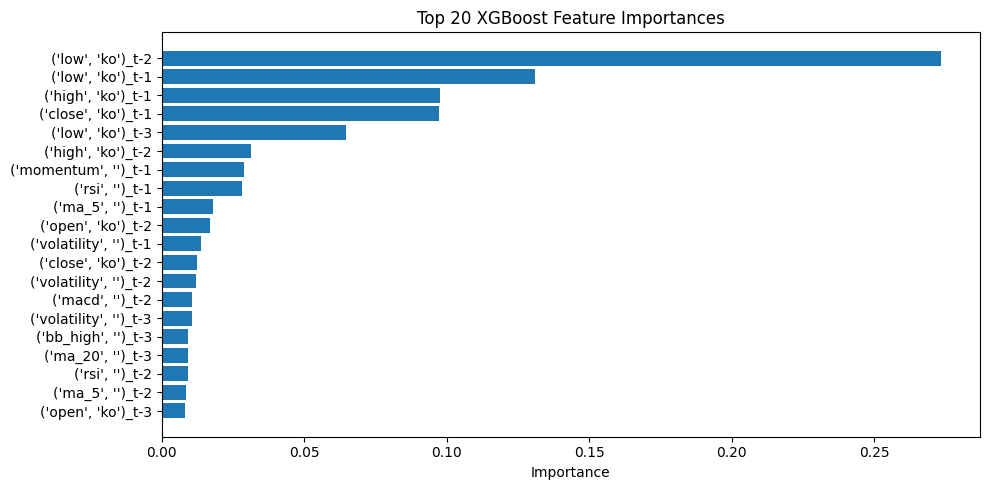

Last available date: 2025-11-10 00:00:00
Predicted close for next day: 70.52


In [53]:
thresholds = [0.001, 0.005, 0.01, 0.02]

print("===Test pruning features===\n")
for threshold in thresholds:
    print(f"Threshold = {threshold}")
    kept_features, metrics = prune_features_by_importance(
        data, lag=lag, train_window=train_window, params=best_params, use_ta=True, threshold=threshold
    )

    # Recreate reduced features
    X, y, target_dates, _ = create_features(data, lag, use_ta=True)
    importances, feature_names = get_feature_importance(data, lag, train_window, best_params, use_ta=True)
    plot_features(importances, feature_names)
    kept_indices = [i for i, name in enumerate(feature_names) if name in kept_features]
    X_reduced = X[:, kept_indices]

    # Train final model on full recent window
    X_train = X_reduced[-train_window:]
    y_train = y[-train_window:]

    final_model = XGBRegressor(**best_params)
    final_model.fit(X_train, y_train)

    next_pred = final_model.predict(X_reduced[-1:].reshape(1, -1))
    last_date = target_dates[-1]

    print(f"Last available date: {last_date}")
    print(f"Predicted close for next day: {next_pred[0]:.2f}")

In [54]:
def plot_sample(X: np.ndarray, y: np.ndarray, target_dates: np.ndarray, feature_dates: list, 
                sample_idx: int = 0, lag: int = 30, ticker: str = "MSFT"):
    """
    Plots the feature vector (closing prices and volumes) for a given sample,
    and shows the next-day target price.

    Args:
        X (np.ndarray): Feature matrix (n_samples, lookback*2)
        y (np.ndarray): Target array (n_samples,)
        sample_idx (int): Index of the sample to visualize
        lookback (int): Number of past days used in features
        ticker (str): Stock ticker for title
    """
    first_features = X[sample_idx]
    first_target = y[sample_idx]
    target_date = target_dates[sample_idx]
    window_dates = feature_dates[sample_idx]

    closes = first_features[:lag]
    volumes = first_features[lag:]

    print(len(window_dates), len(closes), len(volumes))

    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    color = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Close Price', color=color)
    ax1.plot(window_dates, closes, marker='o', color=color, label='Past closes')
    ax1.scatter(target_date, first_target, color='red', label='Next day target')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:green'
    ax2.set_ylabel('Volume', color=color)
    ax2.bar(window_dates, volumes, alpha=0.3, color=color, label='Past volumes')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.title(f'{ticker} - Sample {sample_idx} features (closes + volumes) vs. next-day target')
    plt.show()

In [55]:
print(ticker)
#plot_sample(X, y, target_dates, feature_dates, sample_idx=0, lag=lag, ticker=ticker)

KO
